# Pollution EDA

This notebook explores pollution-related variables in the cleaned CalEnviroScreen dataset. This is the Person 2 section of the group project.


## 1. Import Packages


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)


## 2. Load the Cleaned Dataset


In [18]:
possible_paths = [
    Path("env_clean.csv"),
    Path.home() / "Desktop" / "env_clean.csv"
]

for path in possible_paths:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError("Could not find env_clean.csv. Please upload it to the notebook folder or put it on your Desktop.")

print("Using file:", data_path)

df = pd.read_csv(data_path)
df.head()


Using file: env_clean.csv


,census_tract,county,location,population,PollutionScore,pm25,diesel_pm,traffic_density,ozone,asthma,cardiovascular_disease,diabetes,low_birth_weight
0,6001400100,Alameda,Berkeley,3094,4.369906,7.135387,0.095739,934.715,0.029251,17.36,7.29,9.1,7.03
1,6001400200,Alameda,Oakland,2093,5.046525,7.348713,0.171673,1753.647,0.028516,20.69,7.04,7.0,4.13
2,6001400300,Alameda,Oakland,5727,4.971513,7.446539,0.155387,1617.707,0.028516,26.72,7.51,7.4,4.51
3,6001400400,Alameda,Oakland,4395,4.986183,7.451338,0.160767,1253.706,0.028516,37.93,8.89,6.5,3.06
4,6001400500,Alameda,Oakland,3822,4.496636,7.451338,0.133439,484.944,0.028516,49.55,9.87,7.2,5.50


## 3. Check Dataset Size and Column Names


In [19]:
print("Shape of dataset:", df.shape)
print("Columns:")
print(df.columns.tolist())


Shape of dataset: (8859, 13)
Columns:
['census_tract', 'county', 'location', 'population', 'PollutionScore', 'pm25', 'diesel_pm', 'traffic_density', 'ozone', 'asthma', 'cardiovascular_disease', 'diabetes', 'low_birth_weight']


## 4. Select Pollution Variables


In [20]:
pollution_vars = ["PollutionScore", "pm25", "diesel_pm", "traffic_density", "ozone"]

missing_cols = [col for col in pollution_vars if col not in df.columns]
if missing_cols:
    raise ValueError(f"These columns are missing from the dataset: {missing_cols}")

df[pollution_vars].head()


,PollutionScore,pm25,diesel_pm,traffic_density,ozone
0,4.369906,7.135387,0.095739,934.715,0.029251
1,5.046525,7.348713,0.171673,1753.647,0.028516
2,4.971513,7.446539,0.155387,1617.707,0.028516
3,4.986183,7.451338,0.160767,1253.706,0.028516
4,4.496636,7.451338,0.133439,484.944,0.028516


## 5. Summary Statistics for Pollution Variables


In [21]:
summary_stats = df[pollution_vars].describe().T
summary_stats


,count,mean,std,min,25%,50%,75%,max
PollutionScore,8859.0,5.301724,1.524336,1.281576,4.209017,5.278909,6.386620,10.000000
pm25,8859.0,9.094119,1.615874,5.723898,7.689451,8.935175,10.526820,12.883694
diesel_pm,8859.0,0.100295,0.238499,0.000108,0.027660,0.056034,0.111002,10.910493
traffic_density,8859.0,1007.960993,931.349094,0.000000,386.802000,652.933000,1322.398000,8643.962000
ozone,8859.0,0.046298,0.009860,0.025815,0.040553,0.045806,0.053665,0.070211


## 6. Missing Value Check


In [22]:
missing_values = df[pollution_vars].isna().sum().to_frame(name="missing_values")
missing_values


,missing_values
PollutionScore,0
pm25,0
diesel_pm,0
traffic_density,0
ozone,0


## 7. Histograms: Distribution of Pollution Variables


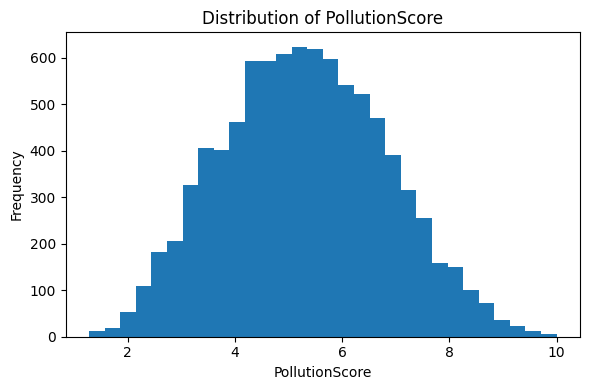

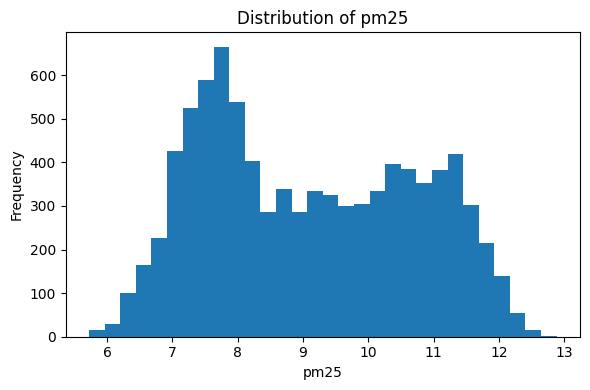

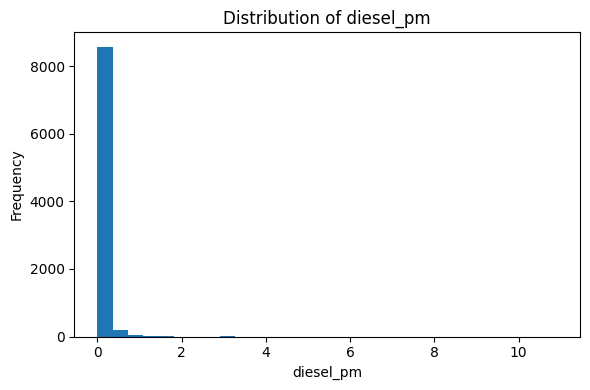

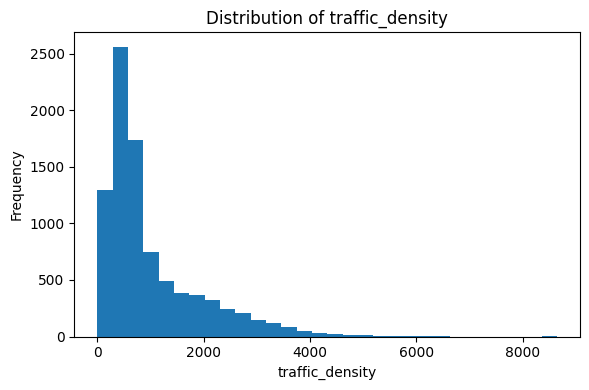

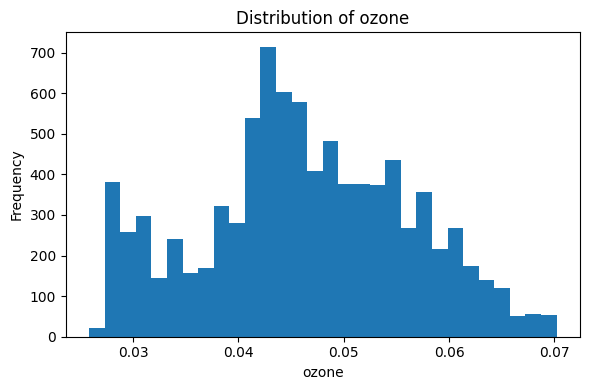

In [23]:
for var in pollution_vars:
    plt.figure(figsize=(6, 4))
    plt.hist(df[var].dropna(), bins=30)
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {var}")
    plt.tight_layout()
    plt.show()


## 8. Boxplots: Outliers in Pollution Variables


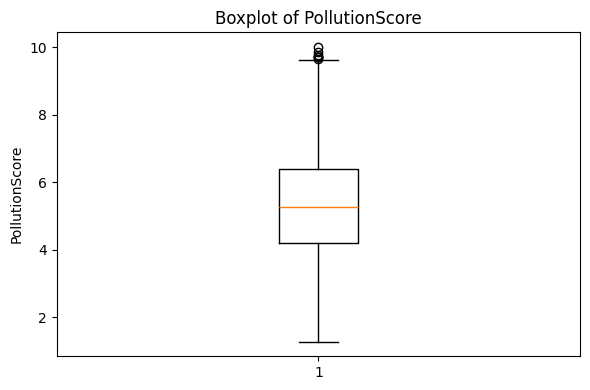

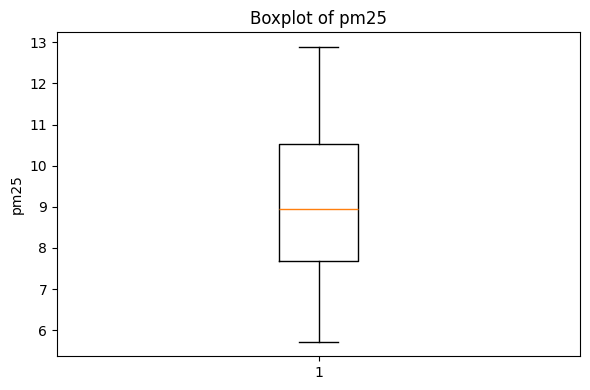

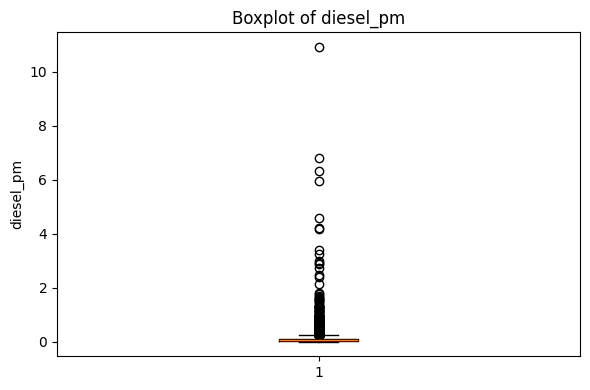

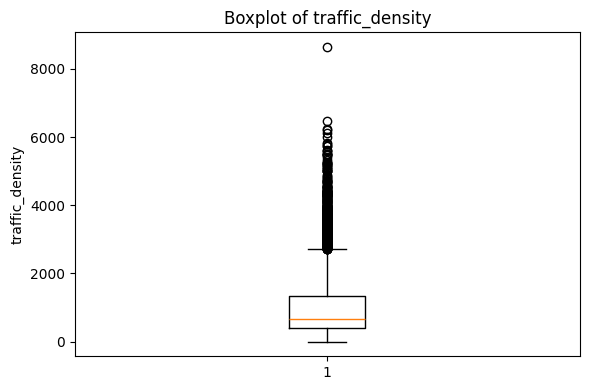

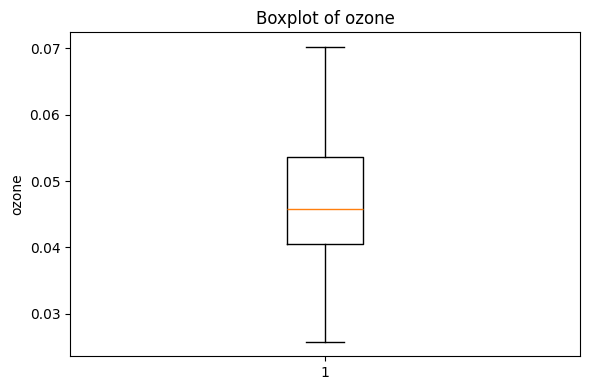

In [24]:
for var in pollution_vars:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[var].dropna())
    plt.ylabel(var)
    plt.title(f"Boxplot of {var}")
    plt.tight_layout()
    plt.show()


## 9. Correlation Table


In [25]:
corr_table = df[pollution_vars].corr()
corr_table


,PollutionScore,pm25,diesel_pm,traffic_density,ozone
PollutionScore,1.000000,0.668081,0.252061,0.405593,0.161910
pm25,0.668081,1.000000,0.143780,0.252710,0.337270
diesel_pm,0.252061,0.143780,1.000000,0.165358,-0.006745
traffic_density,0.405593,0.252710,0.165358,1.000000,-0.010839
ozone,0.161910,0.337270,-0.006745,-0.010839,1.000000


## 10. Correlation Heatmap


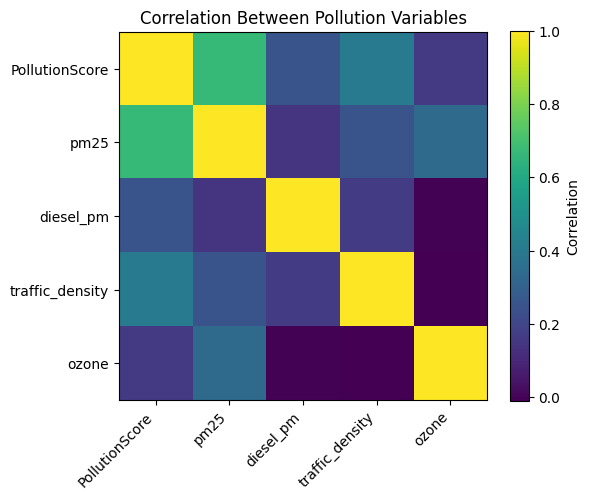

In [26]:
plt.figure(figsize=(6, 5))
plt.imshow(corr_table)

plt.xticks(range(len(pollution_vars)), pollution_vars, rotation=45, ha="right")
plt.yticks(range(len(pollution_vars)), pollution_vars)

plt.colorbar(label="Correlation")
plt.title("Correlation Between Pollution Variables")
plt.tight_layout()
plt.show()


## 11. Scatter Plot: PM2.5 vs Pollution Score


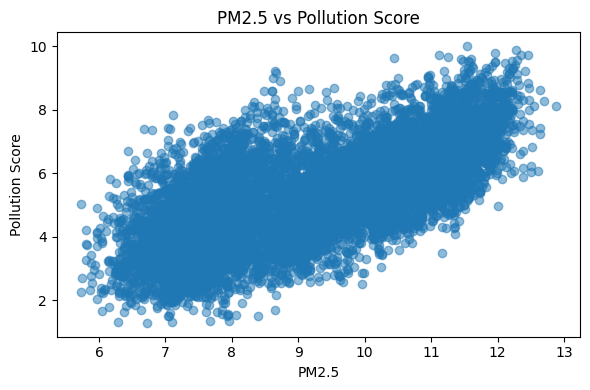

In [27]:
plt.figure(figsize=(6, 4))
plt.scatter(df["pm25"], df["PollutionScore"], alpha=0.5)
plt.xlabel("PM2.5")
plt.ylabel("Pollution Score")
plt.title("PM2.5 vs Pollution Score")
plt.tight_layout()
plt.show()


## 12. Scatter Plot: Traffic Density vs Pollution Score


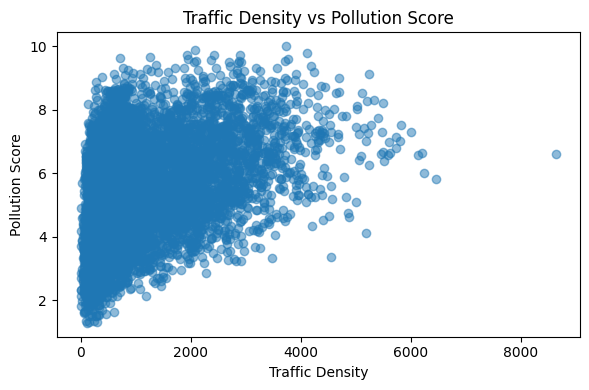

In [28]:
plt.figure(figsize=(6, 4))
plt.scatter(df["traffic_density"], df["PollutionScore"], alpha=0.5)
plt.xlabel("Traffic Density")
plt.ylabel("Pollution Score")
plt.title("Traffic Density vs Pollution Score")
plt.tight_layout()
plt.show()


## 13. Scatter Plot: Diesel PM vs Pollution Score


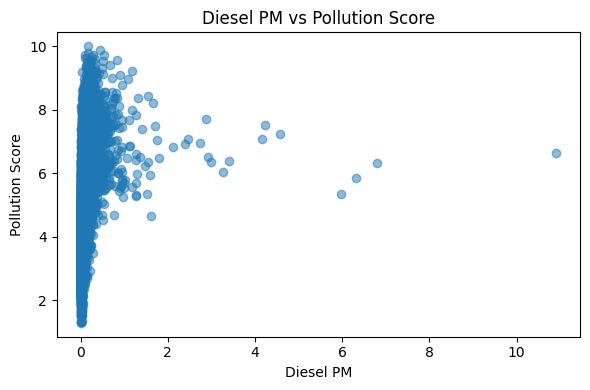

In [29]:
plt.figure(figsize=(6, 4))
plt.scatter(df["diesel_pm"], df["PollutionScore"], alpha=0.5)
plt.xlabel("Diesel PM")
plt.ylabel("Pollution Score")
plt.title("Diesel PM vs Pollution Score")
plt.tight_layout()
plt.show()
